# PhDAI 732 – Fundamentals of AI-Enabled Systems
## Group Project 1 – AI Recommendation System
### Amazon Reviews: Office Products (5-Core)

**Group Members**
- Raja Sankeerth Reddy Cholleti
- Narendar Reddy Katta
- Maaz Zahid Shaikh

**Project objective:** Build and evaluate an AI-enabled product recommendation system using collaborative filtering and Singular Value Decomposition (SVD).

**Dataset:** Amazon Reviews – Office Products 5-core subset (McAuley Lab / SNAP).  
The 5-core subset contains 53,258 reviews, 4,905 users, and 2,420 products. Each retained user and product has at least five reviews.

> **Reproducibility note:** The model uses `random_state=42`. The exact RMSE printed by this notebook should be copied into the final report before submission.


## Team Work Allocation

| Member | Primary Responsibility | Notebook Sections |
|---|---|---|
| **Raja Sankeerth Reddy Cholleti** | Problem definition, dataset selection, integration, interpretation, ethical considerations, final quality review | Sections 1, 2, 7, 9 |
| **Narendar Reddy Katta** | Data loading, cleaning, preprocessing, EDA, visualizations, real-world application | Sections 3-5, 10 |
| **Maaz Zahid Shaikh** | Surprise dataset preparation, SVD modeling, prediction, RMSE/MAE evaluation, hyperparameter tuning, Top-N recommendation logic | Sections 6-8 |

All members review the integrated notebook and report before submission.


## 1. Business Problem and Recommendation Approach — Raja

E-commerce customers face information overload when browsing large product catalogs. The goal of this project is to use historical user-product ratings to predict preferences and support personalized recommendations.

We use **collaborative filtering**, which learns from user-item interaction patterns rather than requiring detailed product attributes. The initial model is **SVD (Singular Value Decomposition)** implemented with the Surprise library.


In [1]:
# Run this cell first in Google Colab.
# If Colab asks you to restart the runtime after package installation, restart and continue.

%pip install -q scikit-surprise

import os
import ast
import gzip
import warnings
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from surprise import Dataset, Reader, SVD, accuracy
from surprise.model_selection import train_test_split, GridSearchCV, cross_validate, KFold

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

RANDOM_STATE = 42
DATA_URL = "https://snap.stanford.edu/data/amazon/productGraph/categoryFiles/reviews_Office_Products_5.json.gz"
DATA_FILE = "reviews_Office_Products_5.json.gz"


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 7.4 MB/s eta 0:00:00


## 2. Dataset Acquisition and Description — Raja

The notebook downloads the public **Amazon Office Products 5-core** review file directly from the Stanford SNAP repository. The raw records include fields such as reviewer ID, product ASIN, rating, review text, helpfulness information, and timestamps.

For collaborative filtering, the essential fields are:

- `reviewerID` → user identifier
- `asin` → product identifier
- `overall` → explicit product rating from 1 to 5


In [2]:
# Download the dataset if it is not already present.
if not os.path.exists(DATA_FILE):
    print("Downloading Amazon Office Products 5-core dataset...")
    urllib.request.urlretrieve(DATA_URL, DATA_FILE)
    print("Download complete.")
else:
    print("Dataset already exists:", DATA_FILE)

print("File:", DATA_FILE)
print("Size (MB):", round(os.path.getsize(DATA_FILE) / (1024**2), 2))


Download complete.
File: reviews_Office_Products_5.json.gz
Size (MB): 17.65


## 3. Load and Inspect the Dataset — Narendar

In [3]:
def load_amazon_reviews(path):
    records = []
    with gzip.open(path, "rt", encoding="utf-8") as f:
        for line in f:
            # The historical Amazon file uses Python-dict-like records.
            records.append(ast.literal_eval(line))
    return pd.DataFrame(records)

raw_df = load_amazon_reviews(DATA_FILE)

print("Raw shape:", raw_df.shape)
display(raw_df.head())
print("\nColumns:")
print(raw_df.columns.tolist())


Raw shape: (53258, 9)


,reviewerID,asin,reviewerName,helpful,reviewText,overall,summary,unixReviewTime,reviewTime
0,A32T2H8150OJLU,B00000JBLH,ARH,"[3, 4]","I bought my first HP12C in about 1984 or so, a...",5.0,"A solid performer, and long time friend",1094169600,"09 3, 2004"
1,A3MAFS04ZABRGO,B00000JBLH,"Let it Be ""Alan""","[7, 9]",WHY THIS BELATED REVIEW? I feel very obliged t...,5.0,"Price of GOLD is up, so don't bury the golden ...",1197676800,"12 15, 2007"
2,A1F1A0QQP2XVH5,B00000JBLH,Mark B,"[3, 3]",I have an HP 48GX that has been kicking for mo...,2.0,"Good functionality, but not durable like old HPs",1293840000,"01 1, 2011"
3,A49R5DBXXQDE5,B00000JBLH,R. D Johnson,"[7, 8]",I've started doing more finance stuff recently...,5.0,One of the last of an almost extinct species,1145404800,"04 19, 2006"
4,A2XRMQA6PJ5ZJ8,B00000JBLH,Roger J. Buffington,"[0, 0]",For simple calculations and discounted cash fl...,5.0,Still the best,1375574400,"08 4, 2013"



Columns:
['reviewerID', 'asin', 'reviewerName', 'helpful', 'reviewText', 'overall', 'summary', 'unixReviewTime', 'reviewTime']


## 4. Data Cleaning and Preprocessing — Narendar

The preprocessing workflow:
1. Selects the user, product, and rating fields required for collaborative filtering.
2. Renames columns to `user_id`, `item_id`, and `rating`.
3. Checks missing values and duplicate user-product-rating records.
4. Removes missing or duplicate records when present.
5. Preserves Amazon reviewer IDs and ASIN product IDs as strings. These identifiers are alphanumeric labels, not numeric measurements.
6. Converts only the `rating` field to floating-point values and verifies the valid 1–5 rating range.


In [4]:
data = raw_df[["reviewerID", "asin", "overall"]].copy()
data.columns = ["user_id", "item_id", "rating"]

print("Before cleaning:", data.shape)
print("\nMissing values:")
print(data.isna().sum())
print("\nExact duplicate rows:", data.duplicated().sum())
print("Duplicate (user_id, item_id) pairs:", data.duplicated(subset=["user_id", "item_id"]).sum())  # more informative than exact-row duplicates for collaborative filtering

# Clean
data = data.dropna().drop_duplicates().copy()
data["user_id"] = data["user_id"].astype(str)
data["item_id"] = data["item_id"].astype(str)
data["rating"] = data["rating"].astype(float)

# Validation
assert data["rating"].between(1, 5).all(), "Ratings outside expected 1–5 range."

print("\nAfter cleaning:", data.shape)
display(data.head())
print("\nData types:")
print(data.dtypes)


Before cleaning: (53258, 3)

Missing values:
user_id    0
item_id    0
rating     0
dtype: int64

Exact duplicate rows: 0
Duplicate (user_id, item_id) pairs: 0

After cleaning: (53258, 3)


,user_id,item_id,rating
0,A32T2H8150OJLU,B00000JBLH,5.0
1,A3MAFS04ZABRGO,B00000JBLH,5.0
2,A1F1A0QQP2XVH5,B00000JBLH,2.0
3,A49R5DBXXQDE5,B00000JBLH,5.0
4,A2XRMQA6PJ5ZJ8,B00000JBLH,5.0



Data types:
user_id     object
item_id     object
rating     float64
dtype: object


## 5. Exploratory Data Analysis (EDA) — Narendar

In [5]:
n_ratings = len(data)
n_users = data["user_id"].nunique()
n_items = data["item_id"].nunique()
mean_rating = data["rating"].mean()
median_rating = data["rating"].median()

possible_interactions = n_users * n_items
density = n_ratings / possible_interactions
sparsity = 1 - density

summary = pd.DataFrame({
    "Metric": [
        "Ratings / interactions",
        "Unique users",
        "Unique products",
        "Mean rating",
        "Median rating",
        "Matrix density",
        "Matrix sparsity"
    ],
    "Value": [
        n_ratings,
        n_users,
        n_items,
        round(mean_rating, 4),
        round(median_rating, 4),
        f"{density:.4%}",
        f"{sparsity:.4%}"
    ]
})

display(summary)

rating_counts = data["rating"].value_counts().sort_index()
rating_pct = (rating_counts / len(data) * 100).round(2)
rating_distribution = pd.DataFrame({
    "count": rating_counts,
    "percent": rating_pct
})
display(rating_distribution)


,Metric,Value
0,Ratings / interactions,53258
1,Unique users,4905
2,Unique products,2420
3,Mean rating,4.346
4,Median rating,5.0
5,Matrix density,0.4487%
6,Matrix sparsity,99.5513%


,count,percent
rating,,
1.0,1130,2.12
2.0,1726,3.24
3.0,5060,9.50
4.0,15015,28.19
5.0,30327,56.94


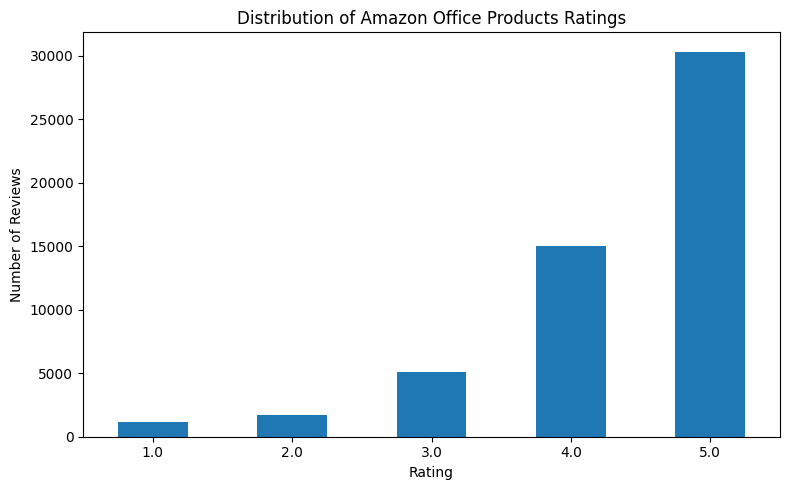

In [6]:
# Figure 1: Rating distribution
plt.figure(figsize=(8, 5))
rating_counts.plot(kind="bar")
plt.title("Distribution of Amazon Office Products Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


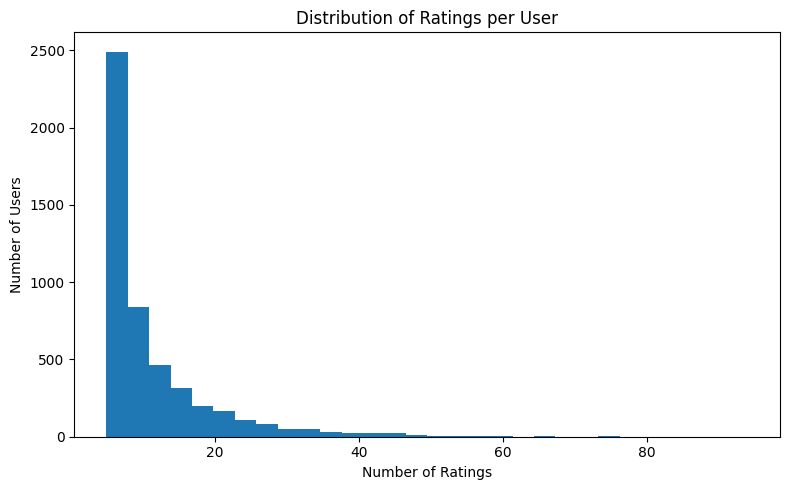

count    4905.000000
mean       10.857900
std         8.741133
min         5.000000
25%         5.000000
50%         7.000000
75%        13.000000
max        94.000000
dtype: float64


In [7]:
# Figure 2: Ratings per user
ratings_per_user = data.groupby("user_id").size()

plt.figure(figsize=(8, 5))
plt.hist(ratings_per_user, bins=30)
plt.title("Distribution of Ratings per User")
plt.xlabel("Number of Ratings")
plt.ylabel("Number of Users")
plt.tight_layout()
plt.show()

print(ratings_per_user.describe())


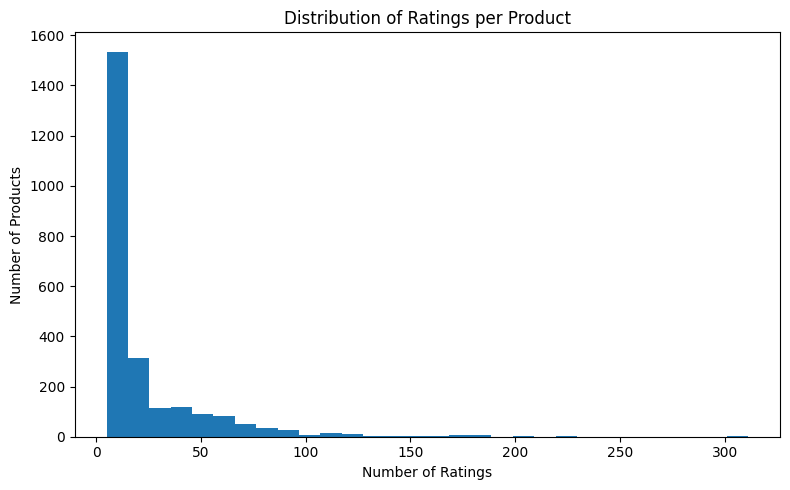

count    2420.000000
mean       22.007438
std        27.552272
min         5.000000
25%         6.000000
50%        10.000000
75%        23.000000
max       311.000000
dtype: float64


In [8]:
# Figure 3: Ratings per product
ratings_per_item = data.groupby("item_id").size()

plt.figure(figsize=(8, 5))
plt.hist(ratings_per_item, bins=30)
plt.title("Distribution of Ratings per Product")
plt.xlabel("Number of Ratings")
plt.ylabel("Number of Products")
plt.tight_layout()
plt.show()

print(ratings_per_item.describe())


In [9]:
# Most frequently rated products (ASINs)
top_products = (
    data.groupby("item_id")
        .agg(number_of_ratings=("rating", "size"),
             average_rating=("rating", "mean"))
        .sort_values("number_of_ratings", ascending=False)
        .head(10)
)
display(top_products)


,number_of_ratings,average_rating
item_id,,
B0010T3QT2,311,4.218650
B0039N7ELS,227,4.533040
B0027CTFBO,205,4.624390
B0039N3QFQ,186,3.994624
B000MFHX3U,185,4.324324
B002K9M6OW,185,4.610811
B002K9GOPE,182,4.769231
B0039N3QO2,182,4.225275
B002K9IHJK,180,4.483333


### EDA Interpretation

After cleaning, the dataset contains **53,258 ratings from 4,905 users on 2,420 products**. The resulting user-product matrix has 11,870,100 possible interactions, but only 53,258 are observed, giving a density of approximately **0.4487%** and sparsity of approximately **99.5513%**. The 5-core construction guarantees at least five reviews per retained user and product, but the matrix remains highly sparse.

The mean rating is **4.3460** and the median is **5.0**, showing a strong positive-rating bias. Ratings of 5 account for 30,327 reviews (**56.94%**) and ratings of 4 account for 15,015 (**28.19%**); together, ratings of 4 or 5 make up approximately **85.13%** of the dataset. This imbalance can make rating prediction appear accurate while making it harder to distinguish among products that users already rate positively.

User activity is uneven: users have a median of **7 ratings** and an average of approximately **10.86**, while products have a median of **10 ratings** and an average of approximately **22.01**. The histograms and top-product table therefore show that some users and products contribute substantially more observations than others. Collaborative filtering can learn more reliable latent factors for these frequently observed entities, but recommendations may favor popular products and be less reliable for users or products near the five-review minimum.

These findings motivate evaluating both predictive error and recommendation quality. RMSE and MAE summarize held-out rating accuracy, while the Top-N output should be checked separately for coverage, popularity concentration, and usefulness.

## 6. Collaborative Filtering Model Development — Maaz

The cleaned data are converted to a Surprise dataset. A 75/25 train-test split is used. SVD learns latent user and product factors from historical ratings and predicts ratings for held-out interactions.


In [10]:
reader = Reader(rating_scale=(1, 5))
data_surprise = Dataset.load_from_df(
    data[["user_id", "item_id", "rating"]],
    reader
)

trainset, testset = train_test_split(
    data_surprise,
    test_size=0.25,
    random_state=RANDOM_STATE
)

print("Training ratings:", trainset.n_ratings)
print("Testing ratings:", len(testset))


Training ratings: 39943
Testing ratings: 13315


In [11]:
svd_model = SVD(random_state=RANDOM_STATE)
svd_model.fit(trainset)

predictions = svd_model.test(testset)

rmse_value = accuracy.rmse(predictions, verbose=True)
mae_value = accuracy.mae(predictions, verbose=True)

print(f"\nInitial SVD RMSE: {rmse_value:.4f}")
print(f"Initial SVD MAE:  {mae_value:.4f}")


RMSE: 0.8508
MAE:  0.6329

Initial SVD RMSE: 0.8508
Initial SVD MAE:  0.6329


## 7. Evaluation and Interpretation — Raja + Maaz

**RMSE** measures the square-root of the average squared difference between actual and predicted ratings. Lower RMSE indicates better predictive accuracy.

Interpret the exact value printed above in the context of a 1–5 rating scale. Also note that rating prediction accuracy alone does not measure recommendation diversity, novelty, fairness, or business usefulness.


In [12]:
# Preview actual vs. predicted ratings
prediction_df = pd.DataFrame(
    [(p.uid, p.iid, p.r_ui, p.est) for p in predictions],
    columns=["user_id", "item_id", "actual_rating", "predicted_rating"]
)
prediction_df["absolute_error"] = (
    prediction_df["actual_rating"] - prediction_df["predicted_rating"]
).abs()

display(prediction_df.head(10))
display(prediction_df["absolute_error"].describe())


,user_id,item_id,actual_rating,predicted_rating,absolute_error
0,A2HMF8ZR67BNZS,B0006OF5MI,5.0,4.607234,0.392766
1,A3TPNC3TKGCCEI,B00ASHH602,5.0,4.741657,0.258343
2,A2AMTEB5UZEOXE,B005K8AUWA,1.0,4.147606,3.147606
3,ATYUQROTHLNYV,B003FHBPRM,4.0,4.325982,0.325982
4,AUAX1QWUCYKSX,B000A0OFXS,4.0,4.233118,0.233118
5,AHUT55E980RDR,B00B80SOW2,5.0,4.860294,0.139706
6,AWAB7PKBO3BBT,B008HSIVVC,3.0,3.996811,0.996811
7,A3H11VW0L01A1T,B00347A8GM,4.0,4.672976,0.672976
8,A26EQ8U96JA92T,B000CCXXQY,4.0,4.846740,0.846740
9,A1F958T2GSWCEK,B004GBGRYM,5.0,4.204550,0.795450


,absolute_error
count,13315.000000
mean,0.632895
std,0.568680
min,0.000000
25%,0.284428
50%,0.496991
75%,0.785647
max,3.976899


## 8. Deliverable 2: Hyperparameter Tuning and Model Optimization — Maaz

This section is required for Deliverable 2. It tunes the SVD model's hyperparameters with `GridSearchCV`, trains a final model with the best parameters found, and evaluates that tuned model against the same held-out test set used for the Deliverable 1 baseline so the two are directly comparable.

In [13]:
# Grid-search SVD hyperparameters. This is a required step for Deliverable 2.
#
# IMPORTANT: GridSearchCV must be fit ONLY on the training ratings, never on
# data_surprise (the full dataset), because data_surprise includes the ratings
# held out in `testset`. Fitting the grid search on the full dataset would let
# hyperparameter selection indirectly "see" the test ratings during
# cross-validation, biasing the final held-out evaluation below. To avoid
# this, a Surprise Dataset is rebuilt using only the raw ratings already
# inside `trainset`.
RUN_TUNING = True

train_rows = [
    (trainset.to_raw_uid(uid), trainset.to_raw_iid(iid), rating)
    for uid, iid, rating in trainset.all_ratings()
]
train_df_for_tuning = pd.DataFrame(train_rows, columns=["user_id", "item_id", "rating"])
tuning_data = Dataset.load_from_df(train_df_for_tuning[["user_id", "item_id", "rating"]], reader)

# Explicit, seeded K-fold splitter so the cross-validation folds themselves are
# reproducible, not just the SVD algorithm and the train/test split.
cv_splitter = KFold(n_splits=3, random_state=RANDOM_STATE, shuffle=True)

param_grid = {
    "n_factors": [50, 100],
    "n_epochs": [20, 40],
    "lr_all": [0.002, 0.005],
    "reg_all": [0.02, 0.05],
    "random_state": [RANDOM_STATE]
}

# Fallback values only used if RUN_TUNING is set to False; replace with the
# actual best_params printed by the grid search once you have run it.
default_params = {
    "n_factors": 100,
    "n_epochs": 20,
    "lr_all": 0.005,
    "reg_all": 0.02,
    "random_state": RANDOM_STATE
}

if RUN_TUNING:
    grid_search = GridSearchCV(
        SVD,
        param_grid,
        measures=["rmse", "mae"],
        cv=cv_splitter,
        n_jobs=-1
    )
    grid_search.fit(tuning_data)  # training ratings only -- test set never touched
    best_params = grid_search.best_params["rmse"]

    # best_score["rmse"] and best_score["mae"] can come from DIFFERENT winning
    # configurations, since each metric is optimized independently. To report
    # a CV RMSE and CV MAE that both describe the SAME (RMSE-optimal) model,
    # cross_validate is run once, specifically on best_params.
    cv_check = cross_validate(SVD(**best_params), tuning_data, measures=["rmse", "mae"], cv=cv_splitter)
    cv_best_rmse = np.mean(cv_check["test_rmse"])
    cv_best_mae = np.mean(cv_check["test_mae"])

    print("Best parameters (selected by CV RMSE):", best_params)
    print("Matching CV RMSE for that configuration:", cv_best_rmse)
    print("Matching CV MAE for that configuration:", cv_best_mae)
else:
    best_params = default_params.copy()
    print("Grid search skipped; using reproducible default parameters:", best_params)

assert best_params["random_state"] == RANDOM_STATE

Best parameters (selected by CV RMSE): {'n_factors': 50, 'n_epochs': 40, 'lr_all': 0.005, 'reg_all': 0.05, 'random_state': 42}
Matching CV RMSE for that configuration: 0.8619626763377859
Matching CV MAE for that configuration: 0.6385690360238088


### Final Model Evaluation — tuned model vs. Deliverable 1 baseline

The tuned hyperparameters are evaluated on the identical 25% held-out test set used for the baseline SVD model in Section 6-7, so the comparison below isolates the effect of tuning rather than any change in the train/test split.

In [14]:
# Train a model with the tuned hyperparameters on the SAME trainset used for
# the baseline, and evaluate on the SAME held-out testset for a fair comparison.
tuned_model = SVD(**best_params)
tuned_model.fit(trainset)

tuned_predictions = tuned_model.test(testset)
tuned_rmse = accuracy.rmse(tuned_predictions, verbose=False)
tuned_mae = accuracy.mae(tuned_predictions, verbose=False)

comparison_df = pd.DataFrame({
    "Model": ["Baseline SVD (Deliverable 1 defaults)", "Tuned SVD (GridSearchCV)"],
    "RMSE": [rmse_value, tuned_rmse],
    "MAE": [mae_value, tuned_mae],
})
comparison_df["RMSE Improvement"] = comparison_df["RMSE"].iloc[0] - comparison_df["RMSE"]
comparison_df["MAE Improvement"] = comparison_df["MAE"].iloc[0] - comparison_df["MAE"]

print(f"Baseline RMSE: {rmse_value:.4f}   Tuned RMSE: {tuned_rmse:.4f}")
print(f"Baseline MAE:  {mae_value:.4f}   Tuned MAE:  {tuned_mae:.4f}")
display(comparison_df)

Baseline RMSE: 0.8508   Tuned RMSE: 0.8483
Baseline MAE:  0.6329   Tuned MAE:  0.6204


,Model,RMSE,MAE,RMSE Improvement,MAE Improvement
0,Baseline SVD (Deliverable 1 defaults),0.850840,0.632895,0.000000,0.000000
1,Tuned SVD (GridSearchCV),0.848273,0.620408,0.002567,0.012488


### Actual vs. Predicted Analysis for the Tuned Model

The assignment asks for an analysis comparing predicted and actual ratings, not just an aggregate metric. The cell below builds a per-prediction table for the tuned model's held-out test predictions, then groups the absolute error by the true rating value to check whether error is concentrated in particular rating levels (as it was for the Deliverable 1 baseline, where a true 1-star rating was predicted at 4.15).

In [15]:
tuned_prediction_df = pd.DataFrame(
    [(p.uid, p.iid, p.r_ui, p.est) for p in tuned_predictions],
    columns=["user_id", "item_id", "actual_rating", "predicted_rating"]
)
tuned_prediction_df["absolute_error"] = (
    tuned_prediction_df["actual_rating"] - tuned_prediction_df["predicted_rating"]
).abs()

print("Sample of 10 tuned-model predictions:")
display(tuned_prediction_df.sample(10, random_state=RANDOM_STATE).round(3))

print("\nMean absolute error by true rating value (tuned model):")
error_by_rating = (
    tuned_prediction_df.groupby("actual_rating")["absolute_error"]
    .agg(["count", "mean"])
    .rename(columns={"count": "n_predictions", "mean": "mean_absolute_error"})
    .round(4)
)
display(error_by_rating)

Sample of 10 tuned-model predictions:


,user_id,item_id,actual_rating,predicted_rating,absolute_error
9145,AK4HKI46S49NA,B002M7XXAI,5.0,4.045,0.955
8583,A3EUSH8DPW75LR,B005J7Y6GS,5.0,4.809,0.191
7405,A1ITRGMT80D5TK,B00FX51WJK,4.0,4.415,0.415
4789,A26EQ8U96JA92T,B005MR4QLU,5.0,4.489,0.511
6571,AWC8CTW8N2XVE,B004GMN2HG,5.0,3.794,1.206
4193,A2MZXLN9TLP1R4,B000J07BRQ,5.0,4.273,0.727
4705,A2E0TJ49NACDBA,B00CRGP8B6,3.0,4.056,1.056
2117,A3M7BCQKSQAK4L,B000TS9ITM,5.0,5.000,0.000
538,AUS5X6IMFLJBD,B000H0T4W8,5.0,4.502,0.498
9161,A2LI3XFHH7LVPL,B00178QQJ8,5.0,4.808,0.192



Mean absolute error by true rating value (tuned model):


,n_predictions,mean_absolute_error
actual_rating,,
1.0,268,2.9150
2.0,424,1.9389
3.0,1242,1.0620
4.0,3804,0.3866
5.0,7577,0.5105


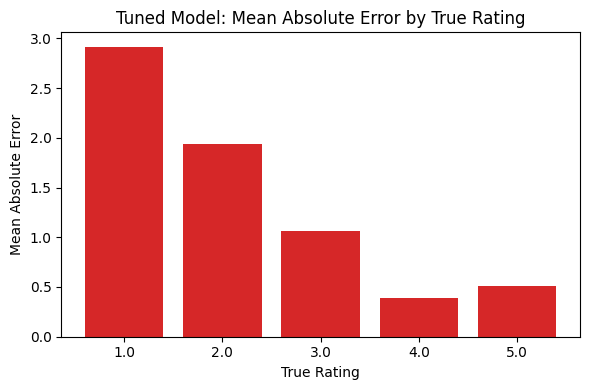

In [16]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(error_by_rating.index.astype(str), error_by_rating["mean_absolute_error"], color="#d62728")
ax.set_xlabel("True Rating")
ax.set_ylabel("Mean Absolute Error")
ax.set_title("Tuned Model: Mean Absolute Error by True Rating")
plt.tight_layout()
plt.savefig("fig5_error_by_rating.png", dpi=150)
plt.show()

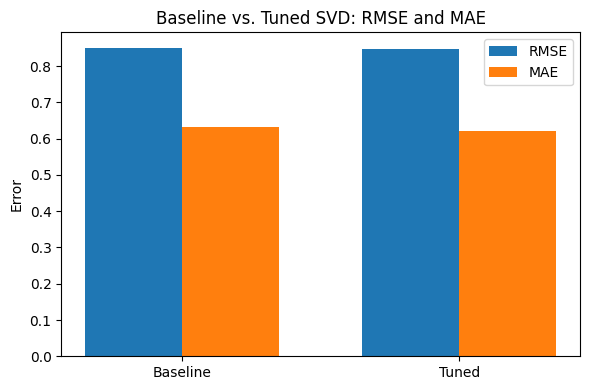

In [17]:
# Visual comparison of baseline vs. tuned model error
fig, ax = plt.subplots(figsize=(6, 4))
x = range(len(comparison_df))
width = 0.35
ax.bar([i - width/2 for i in x], comparison_df["RMSE"], width, label="RMSE")
ax.bar([i + width/2 for i in x], comparison_df["MAE"], width, label="MAE")
ax.set_xticks(list(x))
ax.set_xticklabels(["Baseline", "Tuned"])
ax.set_ylabel("Error")
ax.set_title("Baseline vs. Tuned SVD: RMSE and MAE")
ax.legend()
plt.tight_layout()
plt.savefig("fig4_baseline_vs_tuned.png", dpi=150)
plt.show()

In [18]:
# Train a final model using all available ratings and the selected parameters.
full_trainset = data_surprise.build_full_trainset()

final_model = SVD(**best_params)
final_model.fit(full_trainset)

print("Final model trained on the complete dataset.")


Final model trained on the complete dataset.


### Top-N Recommendations using the Final Tuned Model

The tuned hyperparameters (from the grid search above) are used to fit a model on the complete dataset, which is then used to generate the top 10 recommended products for every user, excluding products they have already rated.

In [19]:
def get_top_n_recommendations(model, raw_user_id, n=10):
    all_items = set(data["item_id"].unique())
    rated_items = set(
        data.loc[data["user_id"] == str(raw_user_id), "item_id"].tolist()
    )

    predictions_for_user = []
    for item_id in sorted(all_items - rated_items):
        estimated_rating = model.predict(str(raw_user_id), str(item_id)).est
        predictions_for_user.append((item_id, estimated_rating))

    predictions_for_user.sort(key=lambda item: (-item[1], item[0]))
    return predictions_for_user[:n]


def get_top_n_for_all_users(model, n=10):
    return {
        user_id: get_top_n_recommendations(model, user_id, n=n)
        for user_id in sorted(data["user_id"].unique())
    }


# Generate Top-N recommendations for every user, excluding products they already rated.
TOP_N = 10
top_n_by_user = get_top_n_for_all_users(final_model, n=TOP_N)
recommendations_df = pd.DataFrame(
    [
        (user_id, rank, item_id, predicted_rating)
        for user_id, recommendations in top_n_by_user.items()
        for rank, (item_id, predicted_rating) in enumerate(recommendations, start=1)
    ],
    columns=["user_id", "rank", "item_id", "predicted_rating"]
)

assert len(top_n_by_user) == data["user_id"].nunique()
assert not recommendations_df.duplicated(["user_id", "item_id"]).any()
assert recommendations_df["rank"].between(1, TOP_N).all()

print(f"Users with recommendations: {len(top_n_by_user):,}")
print(f"Recommendation rows generated: {len(recommendations_df):,}")
print(f"Expected maximum rows: {len(top_n_by_user) * TOP_N:,}")
display(recommendations_df.head(20))


Users with recommendations: 4,905
Recommendation rows generated: 49,050
Expected maximum rows: 49,050


,user_id,rank,item_id,predicted_rating
0,A00473363TJ8YSZ3YAGG9,1,B001S9HWKS,4.737434
1,A00473363TJ8YSZ3YAGG9,2,B000FPGP4U,4.655882
2,A00473363TJ8YSZ3YAGG9,3,B00358RIRC,4.635897
3,A00473363TJ8YSZ3YAGG9,4,B00006IBLJ,4.611320
4,A00473363TJ8YSZ3YAGG9,5,B003J9XN76,4.584503
5,A00473363TJ8YSZ3YAGG9,6,B004K6LHBQ,4.568053
6,A00473363TJ8YSZ3YAGG9,7,B005VC8CK2,4.551332
7,A00473363TJ8YSZ3YAGG9,8,B0028SCBV8,4.549590
8,A00473363TJ8YSZ3YAGG9,9,B004ISGG7Q,4.546612
9,A00473363TJ8YSZ3YAGG9,10,B00D7H8XB6,4.541340


## 9. Ethical Considerations and Limitations — Raja

Key considerations:
- **Privacy:** Interaction histories can reveal user preferences and behavior; identifiers should remain anonymized and access controlled.
- **Bias and popularity effects:** Products with more interactions can receive more visibility, while less-reviewed products may be disadvantaged. This is a form of the popularity bias documented broadly in recommender-system fairness research (Mehrabi et al., 2021).
- **Demographic fairness:** The modeling dataset does not contain demographic attributes such as age or gender, so recommendation quality and error rates cannot be compared across demographic groups. A production system would require carefully governed fairness auditing while avoiding unnecessary collection of sensitive personal information.
- **Transparency:** Users should understand that recommendations are algorithmically generated from historical interactions.
- **Cold start:** Collaborative filtering struggles with new users and new products lacking interaction histories.
- **Historical data:** The selected Amazon review snapshot spans historical review activity and should not be interpreted as a current representation of Amazon's catalog or current customer behavior.
- **Evaluation scope:** RMSE and MAE evaluate rating-prediction error but not ranking quality, novelty, diversity, or fairness; a model can have strong RMSE/MAE while still producing a narrow, low-diversity set of recommendations.
- **Mitigation directions:** Popularity bias can be partially addressed by re-ranking recommendations with diversity or novelty terms, by monitoring exposure across the product catalog rather than only aggregate accuracy, and by being explicit with stakeholders about what the reported metrics do and do not measure.

## 10. Real-World Application and Recommendations — Raja + Narendar

**Application to production e-commerce.** This tuned SVD recommendation model could support an Amazon Office Products storefront as a "Recommended for you" or "Customers also rated highly" module. The Top-N table generated in Section 8 is already in the shape a production system needs: a ranked list of candidate products per user, excluding items the user has already rated. Realistically, this SVD score would be one signal blended with others (in-stock status, price, shipping eligibility, merchandising rules) rather than shown to customers unmodified, and its business value would need to be measured with the same care recommended by Jannach and Jugovac (2019), i.e., through business metrics such as click-through and conversion rather than RMSE alone.

**Improvements for a production environment:**
- **Cold start:** New users or newly listed products have no rating history, so the current model cannot score them; a production system would need a content-based or popularity-based fallback for these cases.
- **Freshness:** SVD as implemented here is trained in a single batch. A production deployment would need a retraining cadence (e.g., nightly or weekly) so recommendations reflect recent behavior and newly added products.
- **Business rule layering:** Out-of-stock, discontinued, or margin-sensitive products would need to be filtered or re-weighted after model scoring, before recommendations reach a customer.
- **Evaluation beyond RMSE:** A/B testing against click-through rate, add-to-cart rate, and revenue per session would validate whether lower prediction error actually improves business outcomes, which is not guaranteed by offline RMSE/MAE alone.
- **Monitoring for popularity concentration:** Given the popularity skew documented in Section 5, a production system should track how concentrated the served recommendations are across the catalog, not only aggregate accuracy, to avoid always recommending the same small set of popular products.

## 11. Final Reproducibility Summary

Run this final cell and copy the reported values into the final written report before submission.

In [20]:
print("=" * 70)
print("FINAL PROJECT SUMMARY")
print("=" * 70)
print(f"Rows after cleaning: {len(data):,}")
print(f"Unique users:        {data['user_id'].nunique():,}")
print(f"Unique products:     {data['item_id'].nunique():,}")
print(f"Mean rating:         {data['rating'].mean():.4f}")
print(f"Matrix sparsity:     {(1 - len(data)/(data['user_id'].nunique()*data['item_id'].nunique())):.4%}")
print(f"Baseline SVD RMSE:   {rmse_value:.4f}")
print(f"Baseline SVD MAE:    {mae_value:.4f}")
print(f"Tuned SVD RMSE:      {tuned_rmse:.4f}")
print(f"Tuned SVD MAE:       {tuned_mae:.4f}")
print(f"Best hyperparameters: {best_params}")
print("=" * 70)

FINAL PROJECT SUMMARY
Rows after cleaning: 53,258
Unique users:        4,905
Unique products:     2,420
Mean rating:         4.3460
Matrix sparsity:     99.5513%
Baseline SVD RMSE:   0.8508
Baseline SVD MAE:    0.6329
Tuned SVD RMSE:      0.8483
Tuned SVD MAE:       0.6204
Best hyperparameters: {'n_factors': 50, 'n_epochs': 40, 'lr_all': 0.005, 'reg_all': 0.05, 'random_state': 42}


## References

- Koren, Y., Bell, R., & Volinsky, C. (2009). Matrix factorization techniques for recommender systems. *Computer, 42*(8), 30–37. https://doi.org/10.1109/MC.2009.263
- Linden, G., Smith, B., & York, J. (2003). Amazon.com recommendations: Item-to-item collaborative filtering. *IEEE Internet Computing, 7*(1), 76–80. https://doi.org/10.1109/MIC.2003.1167344
- McAuley, J., Pandey, R., & Leskovec, J. (2015). Inferring networks of substitutable and complementary products. *Proceedings of the 21st ACM SIGKDD International Conference on Knowledge Discovery and Data Mining*, 785–794.
- McAuley, J., Targett, C., Shi, Q., & van den Hengel, A. (2015). Image-based recommendations on styles and substitutes. *Proceedings of the 38th International ACM SIGIR Conference on Research and Development in Information Retrieval*, 43–52.
- Milano, S., Taddeo, M., & Floridi, L. (2020). Recommender systems and their ethical challenges. *AI & Society, 35*, 957–967. https://doi.org/10.1007/s00146-020-00950-y
- Adomavicius, G., & Tuzhilin, A. (2005). Toward the next generation of recommender systems: A survey of the state-of-the-art and possible extensions. *IEEE Transactions on Knowledge and Data Engineering, 17*(6), 734–749. https://doi.org/10.1109/TKDE.2005.99
- Mehrabi, N., Morstatter, F., Saxena, N., Lerman, K., & Galstyan, A. (2021). A survey on bias and fairness in machine learning. *ACM Computing Surveys, 54*(6), 1-35. https://doi.org/10.1145/3457607
- Jannach, D., & Jugovac, M. (2019). Measuring the business value of recommender systems. *ACM Transactions on Management Information Systems, 10*(4), 1-23. https://doi.org/10.1145/3370082
